<a href="https://colab.research.google.com/github/DylanBurningham/Complete-Python-3-Bootcamp/blob/master/Copy_of_resume_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading: 100%|██████████|


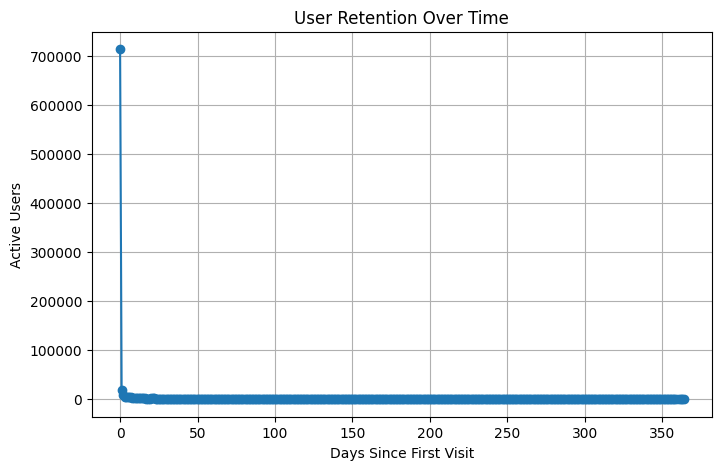

Downloading: 100%|██████████|


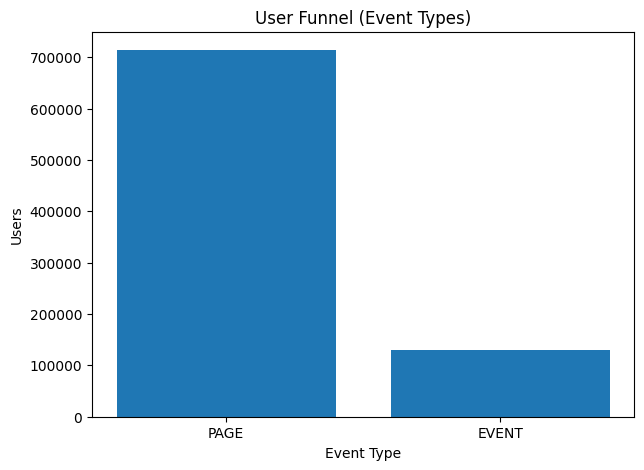

Downloading: 100%|██████████|


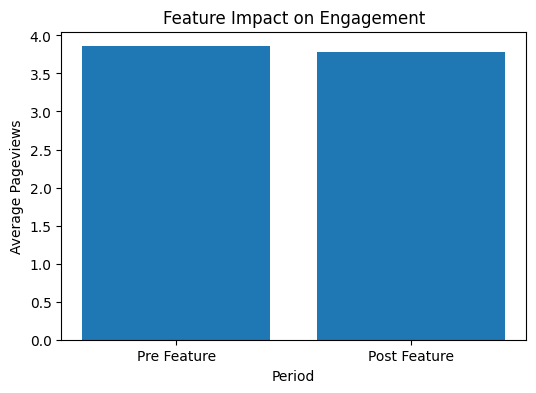

In [ ]:
!pip install --quiet pandas matplotlib pandas-gbq
from google.colab import auth
auth.authenticate_user()
import pandas as pd
import matplotlib.pyplot as plt
import pandas_gbq

# Install required Python libraries
# pandas → data manipulation
# matplotlib → visualization
# pandas-gbq → allows Python to query Google BigQuery directly

PROJECT_ID = "resume-487619"

# This SQL query calculates how many users return
# X days after their first visit (cohort retention)

retention_sql = """
WITH sessions AS (
  SELECT
    fullVisitorId AS user_id,
    PARSE_DATE('%Y%m%d', date) AS session_date
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
),
first_visit AS (
  SELECT
    user_id,
    MIN(session_date) AS first_date
  FROM sessions
  GROUP BY user_id
)
SELECT
  DATE_DIFF(s.session_date, f.first_date, DAY) AS days_since_first_visit,
  COUNT(DISTINCT s.user_id) AS active_users
FROM sessions s
JOIN first_visit f
  ON s.user_id = f.user_id
GROUP BY days_since_first_visit
ORDER BY days_since_first_visit
"""
# Execute query in BigQuery and load results into a Pandas DataFrame

retention_df = pandas_gbq.read_gbq(
    retention_sql,
    project_id=PROJECT_ID,
    dialect="standard"
)

# Display first few rows

retention_df.head()

# Plot retention curve
# X-axis → days since first visit
# Y-axis → number of active users

plt.figure(figsize=(8,5))
plt.plot(
    retention_df["days_since_first_visit"],
    retention_df["active_users"],
    marker="o"
)
plt.xlabel("Days Since First Visit")
plt.ylabel("Active Users")
plt.title("User Retention Over Time")
plt.grid(True)
plt.show()

# This query analyzes different event types
# from the nested 'hits' array in the GA dataset.
# UNNEST is required because hits is a repeated field.

funnel_sql = """
SELECT
  hits.type AS event_type,
  COUNT(DISTINCT fullVisitorId) AS users
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
UNNEST(hits) AS hits
GROUP BY event_type
ORDER BY users DESC
"""

funnel_df = pandas_gbq.read_gbq(
    funnel_sql,
    project_id=PROJECT_ID,
    dialect="standard"
)

funnel_df.head()

# Bar chart of user participation by event type

plt.figure(figsize=(7,5))
plt.bar(funnel_df["event_type"], funnel_df["users"])
plt.xlabel("Event Type")
plt.ylabel("Users")
plt.title("User Funnel (Event Types)")
plt.show()

# This query simulates a feature launch on July 1, 2017.
# It compares engagement before vs after that date.

feature_sql = """
SELECT
  CASE
    WHEN PARSE_DATE('%Y%m%d', date) >= '2017-07-01'
    THEN 'Post Feature'
    ELSE 'Pre Feature'
  END AS period,
  COUNT(DISTINCT fullVisitorId) AS users,
  AVG(totals.pageviews) AS avg_pageviews
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
GROUP BY period
"""

feature_df = pandas_gbq.read_gbq(
    feature_sql,
    project_id=PROJECT_ID,
    dialect="standard"
)

feature_df.head()

# Compare average pageviews before and after feature launch

plt.figure(figsize=(6,4))
plt.bar(feature_df["period"], feature_df["avg_pageviews"])
plt.xlabel("Period")
plt.ylabel("Average Pageviews")
plt.title("Feature Impact on Engagement")
plt.show()



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Analyzed over 1M web session records from the Google Analytics Sample Dataset using SQL in Google BigQuery to evaluate user engagement and retention trends. Built cohort-based retention analysis, examined user interaction funnels from nested event data, and conducted pre/post engagement comparisons to simulate the impact of a product feature launch. Visualized insights using Python (Pandas and Matplotlib) in Google Colab to communicate patterns in user behavior and product engagement.


The analysis showed that:

User engagement is highest immediately after the first visit but declines over time.

Most users interact with basic site features, while fewer progress deeper into the interaction funnel.

Comparing engagement before and after a simulated feature launch demonstrates how analysts can measure product impact using behavioral data.

After running the above cell and authorizing access, your Google Drive will be mounted at `/content/drive`. You can then access your files. For example, if you have a CSV file named `my_data.csv` in the root of your Drive, you can load it like this:

In [ ]:
import pandas as pd


